# End-to-End Pipeline Validation

This notebook writes all generated artifacts to `outputs/`.

## Purpose

Validate the production pipeline end-to-end. This uses the real router: direct extraction when useful annotation exists, otherwise tblastn.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd

from app.validation._shared.validation_utils import *

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
DATASETS = [
    ('PRRS', DATA / 'PRRS_ref_test.gb', CROSS_CHECK / 'PRRS_100seq_anno.gb'),
    ('FMD', DATA / 'FMD_ref_test.gb', CROSS_CHECK / 'FMD_100seq_anno.gb'),
]

frames = []
summaries = []
for virus, ref_path, query_path in DATASETS:
    df, summary = run_production_pipeline_against_truth(virus, ref_path, query_path, OUTPUT_DIR / virus.lower())
    frames.append(df)
    summaries.append(summary)

e2e_df = pd.concat(frames, ignore_index=True)
e2e_summary = pd.concat(summaries, ignore_index=True)
e2e_df.to_csv(OUTPUT_DIR / 'e2e_per_prediction.tsv', sep='\t', index=False)
e2e_summary.to_csv(OUTPUT_DIR / 'e2e_summary.tsv', sep='\t', index=False)
e2e_summary

  [WARN] EU106888.1: 1 feature(s) skipped (ambiguous name, cannot resolve to canonical): ['non-structural protein']
  [WARN] EU236259.1: 1 feature(s) skipped (ambiguous name, cannot resolve to canonical): ['non-structural protein']
  [WARN] EU825723.1: 1 feature(s) skipped (ambiguous name, cannot resolve to canonical): ['non-structural protein']
  [WARN] EU825724.1: 1 feature(s) skipped (ambiguous name, cannot resolve to canonical): ['non-structural protein']
  [WARN] EU807840.1: 2 feature(s) skipped (ambiguous name, cannot resolve to canonical): ['nsp1', 'nsp7']


,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,PRRS,direct,833,783,783,0.9415,94.00,94.00
1,FMD,direct,1178,1173,1173,0.9958,99.58,99.58


In [3]:
status_summary = (
    e2e_df.groupby(['virus', 'method', 'status'])
    .size()
    .reset_index(name='count')
    .sort_values(['virus', 'method', 'count'], ascending=[True, True, False])
)
status_summary.to_csv(OUTPUT_DIR / 'e2e_status_summary.tsv', sep='\t', index=False)
status_summary

,virus,method,status,count
0,FMD,direct,ok,1178
2,PRRS,direct,ok,788
1,PRRS,direct,not_in_reference,45


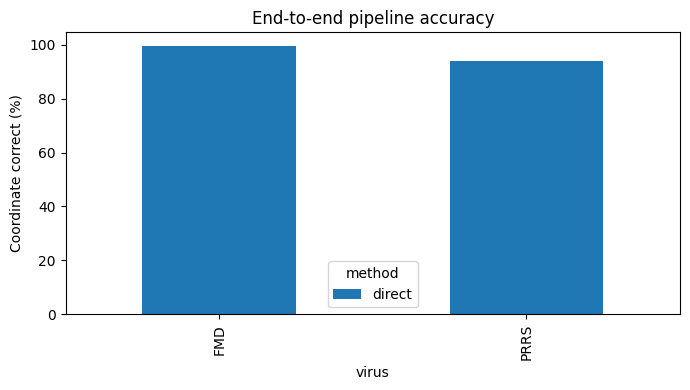

In [4]:
import matplotlib.pyplot as plt

ax = e2e_summary.pivot(index='virus', columns='method', values='coord_pct').plot(kind='bar', figsize=(7, 4))
ax.set_ylabel('Coordinate correct (%)')
ax.set_title('End-to-end pipeline accuracy')
ax.figure.tight_layout()
ax.figure.savefig(OUTPUT_DIR / 'e2e_accuracy.png', dpi=150)